# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

****advantages and disadvantages of showing nitrate and phosphate levels (over the course of a year) as an area plot as opposed to two separate line graphs:**

advantages:  can easily see how the cumulative load (total) of the two series over time.

disadvantages:  harder to tell exact values of the series that is on top.  takes the brain some time to figure that out.  also sometimes it takes the brain to wrap itself around what the top series is doing....this isn't the case if both are separate lines.   its very easy to see the trends instantly.

**how would i adjust the graphs shown to improve presentation:****

I would put both lines plots together since their scale is similar, would make each line a different color and add legend accordingly.  in the stacked plot the legend needs to say which nutrient it is rather than what series it is.  make the color a bit transparent as well as that color seems a bit harsh to my eyes.



In [1]:
!pip install numpy pandas seaborn

import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

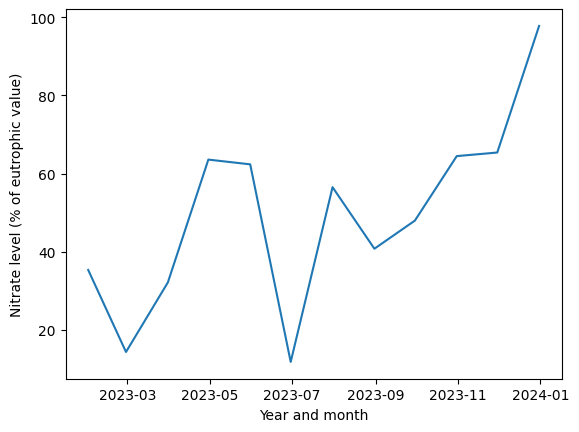

In [2]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

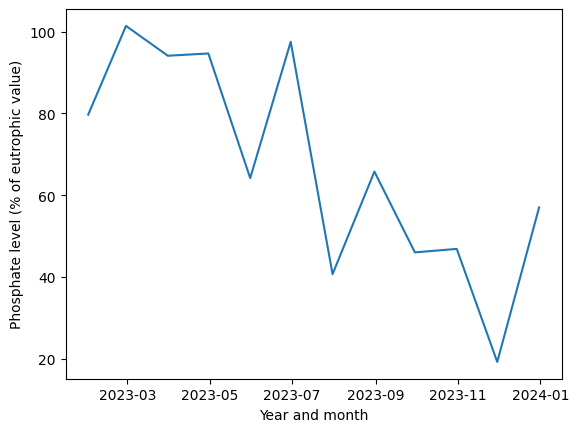

In [3]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

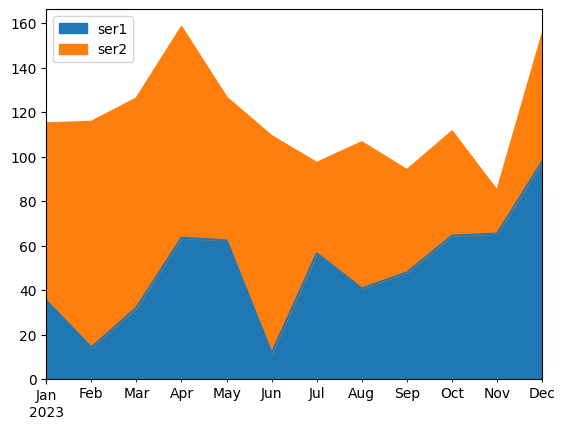

In [4]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

In [5]:
df = pd.read_csv("accident.csv")
df.head
df.columns.tolist()

['STATE',
 'STATENAME',
 'ST_CASE',
 'PEDS',
 'PERNOTMVIT',
 'VE_TOTAL',
 'VE_FORMS',
 'PVH_INVL',
 'PERSONS',
 'PERMVIT',
 'COUNTY',
 'COUNTYNAME',
 'CITY',
 'CITYNAME',
 'MONTH',
 'MONTHNAME',
 'DAY',
 'DAYNAME',
 'DAY_WEEK',
 'DAY_WEEKNAME',
 'YEAR',
 'HOUR',
 'HOURNAME',
 'MINUTE',
 'MINUTENAME',
 'TWAY_ID',
 'TWAY_ID2',
 'ROUTE',
 'ROUTENAME',
 'RUR_URB',
 'RUR_URBNAME',
 'FUNC_SYS',
 'FUNC_SYSNAME',
 'RD_OWNER',
 'RD_OWNERNAME',
 'NHS',
 'NHSNAME',
 'SP_JUR',
 'SP_JURNAME',
 'MILEPT',
 'MILEPTNAME',
 'LATITUDE',
 'LATITUDENAME',
 'LONGITUD',
 'LONGITUDNAME',
 'HARM_EV',
 'HARM_EVNAME',
 'MAN_COLL',
 'MAN_COLLNAME',
 'RELJCT1',
 'RELJCT1NAME',
 'RELJCT2',
 'RELJCT2NAME',
 'TYP_INT',
 'TYP_INTNAME',
 'REL_ROAD',
 'REL_ROADNAME',
 'WRK_ZONE',
 'WRK_ZONENAME',
 'LGT_COND',
 'LGT_CONDNAME',
 'WEATHER',
 'WEATHERNAME',
 'SCH_BUS',
 'SCH_BUSNAME',
 'RAIL',
 'RAILNAME',
 'NOT_HOUR',
 'NOT_HOURNAME',
 'NOT_MIN',
 'NOT_MINNAME',
 'ARR_HOUR',
 'ARR_HOURNAME',
 'ARR_MIN',
 'ARR_MINNAME',
 'H

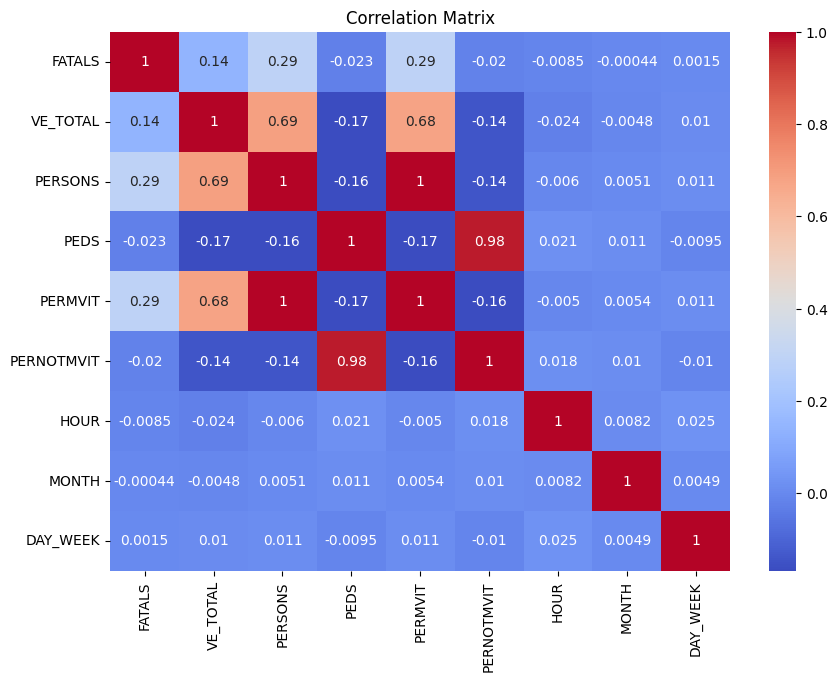

In [6]:
analysis_df = df[
    ['FATALS',
     'VE_TOTAL',
     'PERSONS',
     'PEDS',
     'PERMVIT',
     'PERNOTMVIT',
     'HOUR',
     'MONTH',
     'DAY_WEEK']]

corr = analysis_df.corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

"persons" and "permvit" show a correlation of 1.   this makes sense because "Persons" counts total people invovled in the carash and "Permvit" counts motor vehicle operators and because most crash participants are vehicle occupants then these variables will track w each other almost identically.   these variables are redundant and one of them can be removed in future modeling.

almost the same correlation (0.98 in this instance) is seen between "peds" and "pernotmvit".  this also makes sense as "peds" counts pedestrians and "pernotmvit" counts people not in motor vehicle.  since most non vehicle occupants are pedestrians these two variables almost perfectly overlap and are redundant and one of them can be removed before modeling.

Hour, month, day_week do not show much correlation.  Timing (day, month, week)does not appear to correlate with traffic fatalities.  Though you would think that more traffic accidents would happen at night.  perhaps a line plot would show that whereas a correlation might miss that time series dependentness?

**Vehicles and persons:**

"ve_total" and "persons (people in car)" shows correlation of .69
"ve_total" and "permvit (motor vehicle operators)" shows correlation of .68

this makes sense as accidents involving more vehicles generally will involve more people

**a few small negative correlations appear**

"peds" and "ve_total" shows correlation of -0.17
"peds" and "persons" shows correlation of -0.16

this can ve interpreted as pedestrian crashes tend to involve fewer vehicles and people.  this makes sense because many pedestrian fatalities occur in single vehicle accidents.



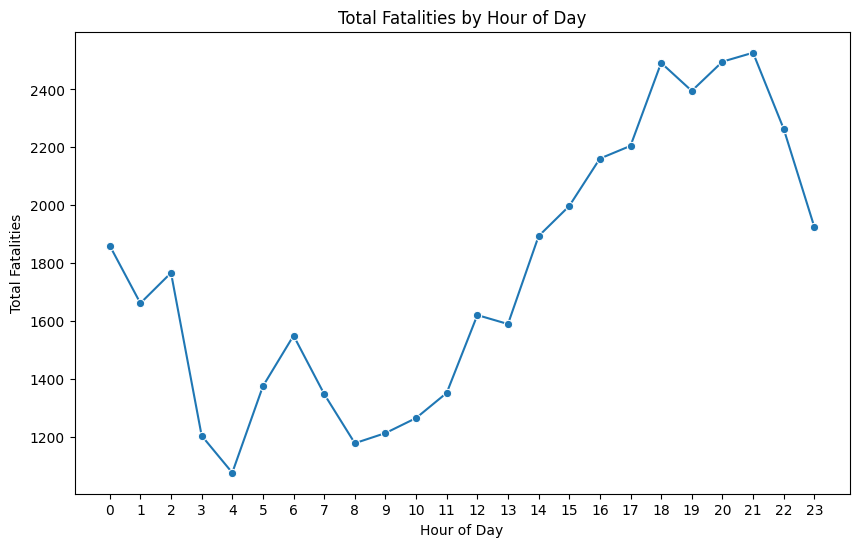

In [7]:
hour_df = analysis_df[analysis_df["HOUR"] != 99]

fatalities_by_hour = hour_df.groupby("HOUR")["FATALS"].sum().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=fatalities_by_hour, x="HOUR", y="FATALS", marker="o")

plt.title("Total Fatalities by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Total Fatalities")
plt.xticks(range(0,24))

plt.show()

the above plot shows that even though hour of day overall shows little correlation with fatalities there is definitely some time dependentness in the hour of day variable.   we see fatalites peak once darkness settles in and then gets lower in the middle of the night when there are less cars out to cause accidents.  Correlation only measures linear relationships and may not capture patterns such as peaks in nighttime or weekend crashes.

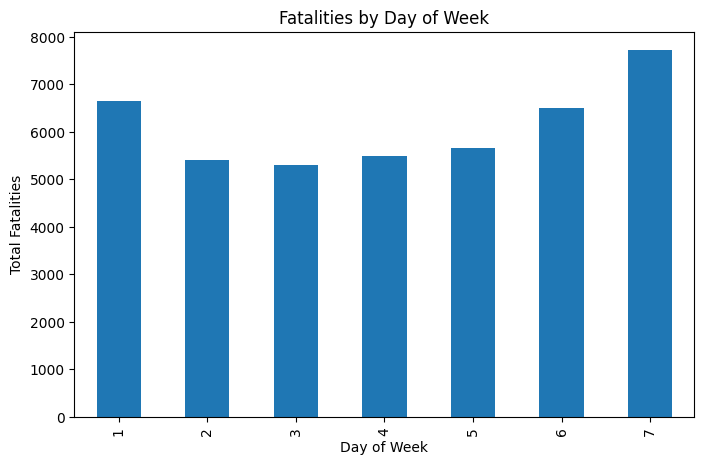

In [8]:
fatalities_by_day = analysis_df.groupby("DAY_WEEK")["FATALS"].sum()

plt.figure(figsize=(8,5))
fatalities_by_day.plot(kind="bar")

plt.title("Fatalities by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Total Fatalities")

plt.show()

the above plot shows that even though day_weeek overall shows little correlation with fatalities there is definitely some time dependentness in the h variable.   we see fatalites peak on the weekend (friday-sun....6,7, and 1 in the bar chart).

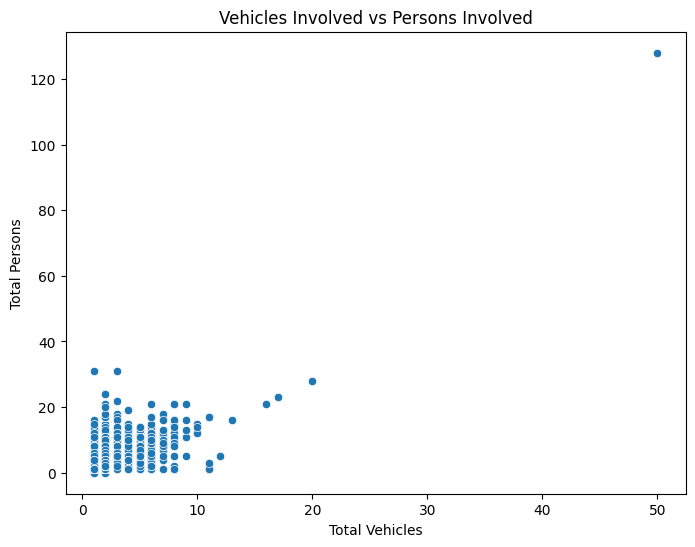

In [9]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=analysis_df, x="VE_TOTAL", y="PERSONS")

plt.title("Vehicles Involved vs Persons Involved")
plt.xlabel("Total Vehicles")
plt.ylabel("Total Persons")

plt.show()

the above scatter plot has a correlation of .69 (from heatmap).   the scatter plot below has a lower correlation of .29 (from heatmap).  the scatter plot below that one has an even lower correlation of .14 (from heatmap)

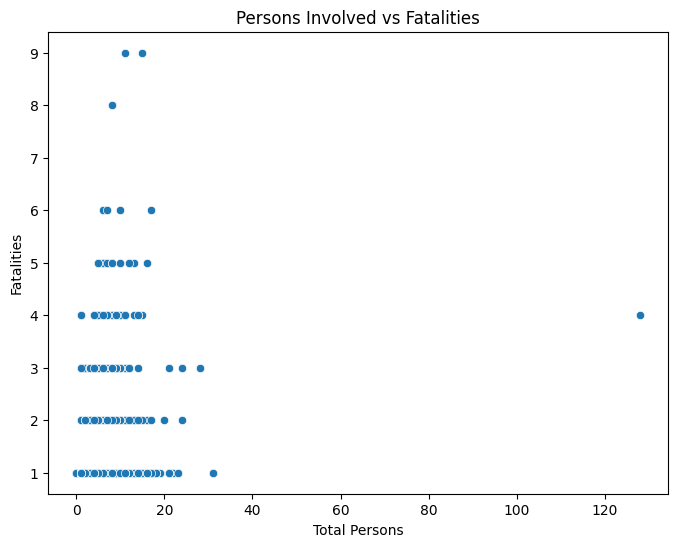

In [10]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=analysis_df, x="PERSONS", y="FATALS")

plt.title("Persons Involved vs Fatalities")
plt.xlabel("Total Persons")
plt.ylabel("Fatalities")

plt.show()

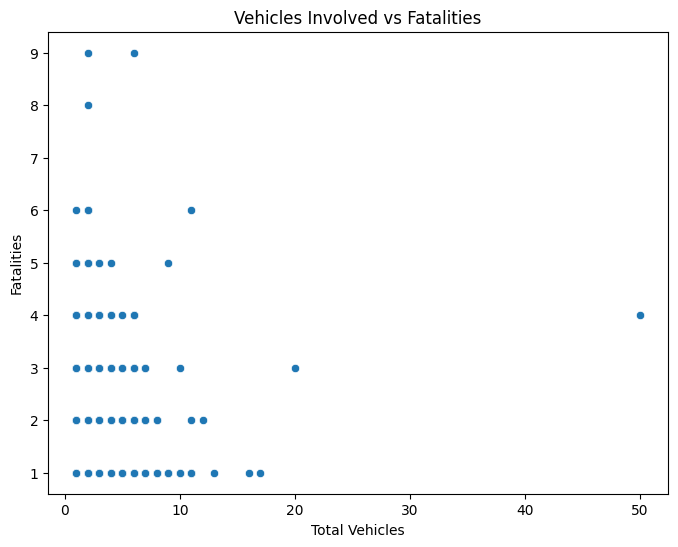

In [11]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=analysis_df, x="VE_TOTAL", y="FATALS")

plt.title("Vehicles Involved vs Fatalities")
plt.xlabel("Total Vehicles")
plt.ylabel("Fatalities")

plt.show()

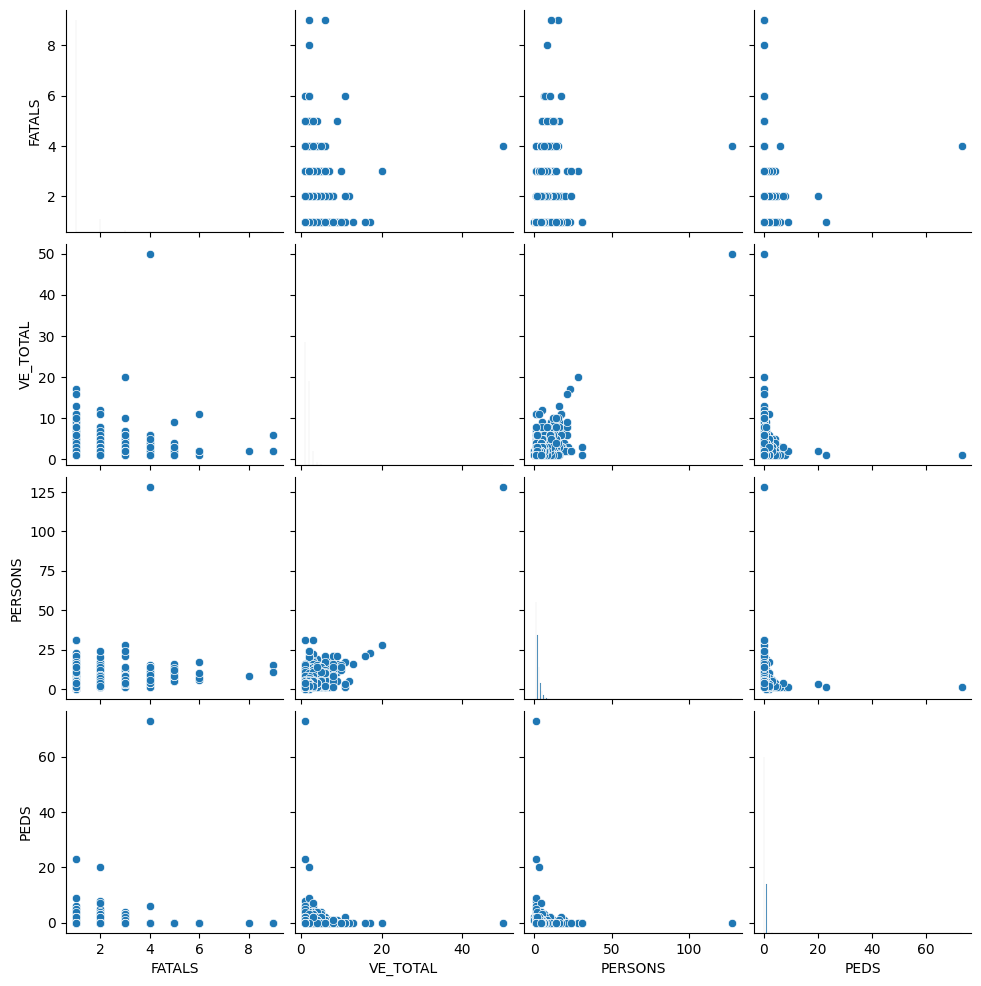

In [12]:
pairplot_vars = analysis_df[["FATALS", "VE_TOTAL", "PERSONS", "PEDS"]]

sns.pairplot(pairplot_vars)

plt.show()

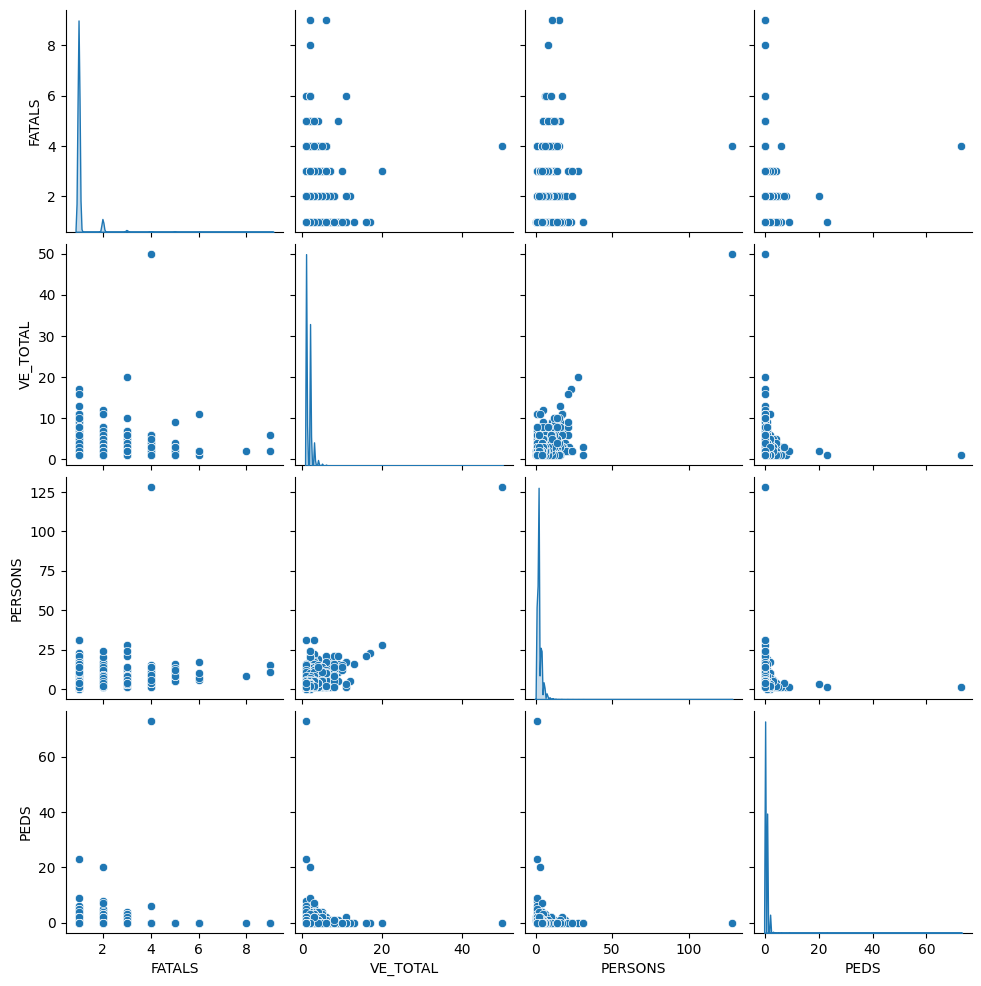

In [13]:
sns.pairplot(analysis_df[["FATALS","VE_TOTAL","PERSONS","PEDS"]], diag_kind="kde")

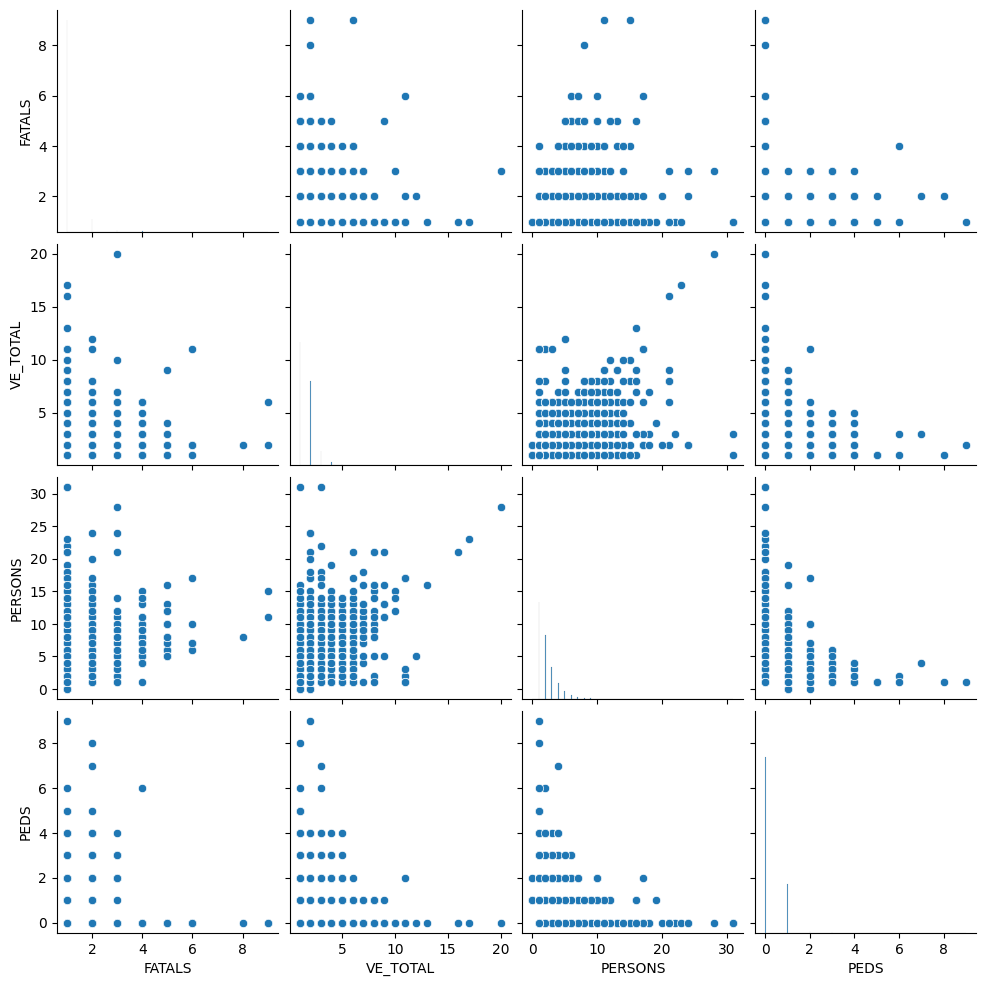

In [ ]:
pair_df = analysis_df[
    (analysis_df["VE_TOTAL"] <= 20) &
    (analysis_df["PERSONS"] <= 40) &
    (analysis_df["PEDS"] <= 10)]

sns.pairplot(pair_df[["FATALS", "VE_TOTAL", "PERSONS", "PEDS"]])

plt.show()

pairplots above show a broad view of the relationships between several (4 in this instance) simultaneously.

pairplot confirms strong relationship betwen vehicles involved and persons involved (see row2, column 3).   this reinforces the correlation analysis above.

the plots also show that fatalities are generally clustered at lower values (few or no fatalities).   there is some upward trend shown between fatalities and persons involved (see row 3 column 1) but the spread of the points indicates a weak overall correlation.  this suggests that atalties cannot be predicte soley from the number of people or vehicles involved in a crash.

pairplots also show distribution of each variable (diagonal axis).  these histograms show that most crashes have a relatively small number of vehicles and people with higher vehicle number and person number appearing less frequently.

overall the dataset apppears very usable.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

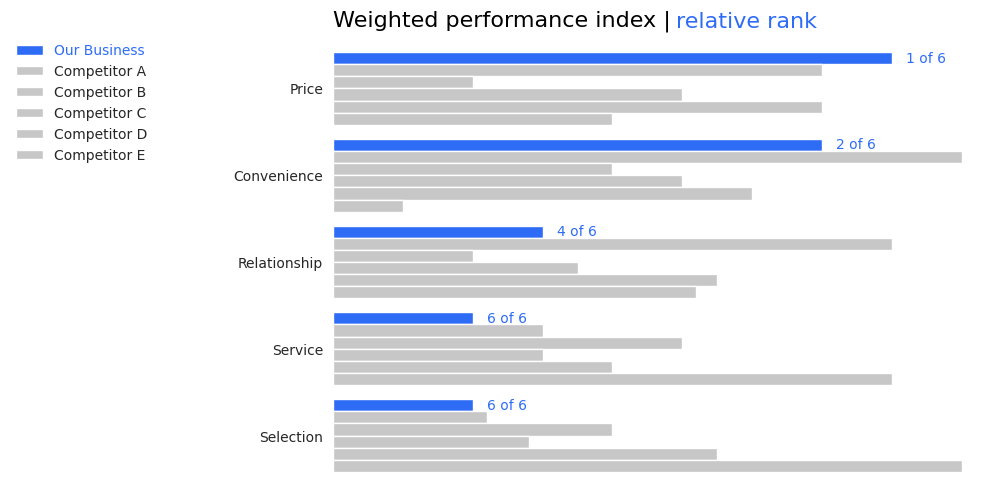

In [16]:
from matplotlib.patches import Patch

blue = "#2E6CF6"
grey = "#C7C7C7"

categories = ["Selection","Service","Relationship","Convenience","Price"]

data = {
    "Our Business":[2,2,3,7,8],
    "Competitor A":[2.2,3,8,9,7],
    "Competitor B":[4,5,2,4,2],
    "Competitor C":[2.8,3,3.5,5,5],
    "Competitor D":[5.5,4,5.5,6,7],
    "Competitor E":[9,8,5.2,1,4],}

df = pd.DataFrame(data, index=categories)

rank_labels = [
    "6 of 6",
    "6 of 6",
    "4 of 6",
    "2 of 6",
    "1 of 6"]

sns.set_style("white")

fig, ax = plt.subplots(figsize=(12,6))

y = np.arange(len(categories))

series = [
    "Our Business",
    "Competitor A",
    "Competitor B",
    "Competitor C",
    "Competitor D",
    "Competitor E"]

bar_height = 0.14
n = len(series)

for i, s in enumerate(series):

    offset = ((n-1)/2 - i) * bar_height
    values = df[s].values
    color = blue if s=="Our Business" else grey

    ax.barh(y + offset, values, height=bar_height, color=color)

    if s == "Our Business":
        for j,v in enumerate(values):
            ax.text(
                v + 0.2,
                y[j] + offset,
                rank_labels[j],
                va="center",
                color=blue,
                fontsize=10)

ax.set_yticks(y)
ax.set_yticklabels(categories)

ax.set_xticks([])
sns.despine(left=True, bottom=True)

ax.text(
    0.0, 1,
    "Weighted performance index | ",
    transform=ax.transAxes,
    fontsize=16,
    ha="left",
    va="bottom",
    color="black")

ax.text(
    0.52, 1,
    "relative rank",
    transform=ax.transAxes,
    fontsize=16,
    ha="left",
    va="bottom",
    color=blue)

legend_elements = [
    Patch(facecolor=blue, label="Our Business"),
    Patch(facecolor=grey, label="Competitor A"),
    Patch(facecolor=grey, label="Competitor B"),
    Patch(facecolor=grey, label="Competitor C"),
    Patch(facecolor=grey, label="Competitor D"),
    Patch(facecolor=grey, label="Competitor E"),]

legend = ax.legend(
    handles=legend_elements,
    loc="upper left",
    bbox_to_anchor=(-0.5, 1),
    frameon=False)

legend.get_texts()[0].set_color(blue)

fig.subplots_adjust(left=0.35)

plt.show()